In [524]:
ENABLE_LIVE_UPDATE = False

In [24]:
from ftplib import FTP
import io
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import struct
import datetime

def update_data():
    with FTP('172.16.100.50') as ftp:
        print(ftp.getwelcome())

        ftp.login(user='flow',passwd='flow')
        byte_reader = io.BytesIO()
        ftp.retrbinary('RETR test_log.csv',byte_reader.write)
        
    csv_string = byte_reader.getvalue().decode("utf-8")
    df = pd.read_csv(StringIO(str(csv_string)))
    return df

def graph_data(df):
    fig,ax = plt.subplots()

    ax.scatter(df['SYS'],df['UP'])
    plt.figure()

    plt.scatter(df['SYS_ZEROED_MS'],df['DOWN'])
    plt.figure()
    plt.scatter(df['SYS_ZEROED_MS'],df['AMB32'])


def int_to_float32(val):
    # Pack as standard integer, unpack as float
    return struct.unpack('!f', struct.pack('!I', val))[0]

def full_log_to_individual_bytes(df):
    dut_dfs = [
        df[[f'DUT{i}', f'UP{i}', f'DOWN{i}', f'AMB32{i}', f'SYS{i}']].rename(columns={
            f'DUT{i}': 'DUT',
            f'UP{i}': 'UP',
            f'DOWN{i}': 'DOWN',
            f'AMB32{i}': 'AMB32',
            f'SYS{i}': 'SYS'
        })
        for i in range(1, 6)
    ]
    # if len(dut_dfs) > 0:
    #     print(dut_dfs[0].head())

    return dut_dfs

def process_data_log(df):
    if(len(df) < 1):
        return

    # df = df[df['SYS'] != 0].reset_index(drop=True)

    # df = df[(df[['UP', 'DOWN', 'AMB32', 'SYS']] != 0).all(axis=1)]
    try:
        min_sys = min(df['SYS'])
    except:
        min_sys = 0
    df['SYS'] = (df['SYS'] - min_sys)/1000
    df['UP'] = (df['UP'] / 16 + 9.8)/196.686
    df['DOWN'] = (df['DOWN'] / 16 + 9.8)/196.686
    df['AMB32'] = df['AMB32'].apply(int_to_float32)
    try:
        seconds = max(df['SYS'])-min(df['SYS'])
        print('Tests ran for' + str(datetime.timedelta(seconds=seconds)))
    except:
        pass
    return df




In [21]:
raw_df = update_data()
print(f'Pulled test_log.csv with length: {len(raw_df)}')
print(raw_df)
# print(f'Data head\n{raw_df.head()}')

# split_df = full_log_to_individual_bytes(raw_df)

# print(f'Successfuly split into {len(split_df)} dataframes')
# print(f'{split_df[0].head()}')

split_df = [df[df.index > 1] for df in split_df]
split_df = [process_data_log(df) for df in split_df]

fig,ax_up = plt.subplots()
ax_up.set_xlabel('Measurement #')
ax_up.set_ylabel('Upstream Normalized Voltage Out (mV)')
ax_up.set_title('Normalized Upstream RTD Voltage vs. Measurement Index after Heat Impulse')

fig,ax_down = plt.subplots()
ax_down.set_xlabel('Measurement #')
ax_down.set_ylabel('Downstream Normalized Voltage Out (mV)')
ax_down.set_title('Normalized Downstream RTD Voltage vs. Measurement Index after Heat Impulse')

fig,ax_amb = plt.subplots()
ax_amb.set_xlabel('Measurement #')
ax_amb.set_ylabel('Ambient Normalized Voltage Out (mV)')
ax_amb.set_title('Normalized Ambient RTD Voltage vs. Measurement Index after Heat Impulse')

fig,ax_amb_norm = plt.subplots()
window_size = 10
ax_amb_norm.set_xlabel('Measurement #')
ax_amb_norm.set_ylabel('Ambient Normalized Voltage Out (mV)')
ax_amb_norm.set_title(f'MOVING AVERAGE (win={window_size}) of Normalized Ambient RTD Voltage vs. Measurement Index after Heat Impulse')


    
# for i,df in enumerate(split_df):
    # print(df.head())
    # try:
    #     raise ValueError
    #     ax_up.scatter(df.index,df['UP']-min(df['UP']),label=f'DUT{i+1}');
    #     ax_down.scatter(df.index,((df['DOWN']-min(df['DOWN']))).rolling(window=1, center=False).mean(),label=f'DUT{i+1}');
    #     ax_amb.scatter(df.index,df['AMB32']-min(df['AMB32']),label=f'DUT{i+1}');
    #     ax_amb_norm.scatter(df.index,(df['AMB32']-min(df['AMB32'])).rolling(window=window_size, center=True).mean(),label=f'DUT{i+1}');

    # except: 
    #     ax_up.scatter(df.index,df['UP'],label=f'DUT{i+1}')
    #     ax_down.scatter(df.index,df['DOWN'],label=f'DUT{i+1}')
    #     ax_amb.scatter(df.index,df['AMB32'],label=f'DUT{i+1}')
# df = split_df[1]
# ax_up.scatter(df.index,df['UP'])
# ax_down.scatter(df.index,df['DOWN'])
# ax_amb.scatter(df.index,df['AMB32'])
# ax_up.legend()
# ax_down.legend()
# ax_amb.legend()
# ax_amb_norm.legend()

# graph_data(df)

220 Wind River FTP server 6.8 ready.
Pulled test_log.csv with length: 39
    target  flow_actual        UP      DOWN       AMB32        SYS
0        0     -1.36674  0.657820  0.626766  1082287896  247480512
1        0     -1.36029  0.657785  0.626726  1082287896  247481501
2        0     -1.35705  0.657703  0.626636  1082287894  247483461
3        0     -1.36995  0.657625  0.626548  1082287894  247485371
4        0     -1.37312  0.657513  0.626418  1082287894  247488355
5        0     -1.35784  0.657435  0.626336  1082287893  247490317
6        0     -1.35594  0.657359  0.626249  1082287892  247492277
7        0     -1.35839  0.657281  0.626167  1082287891  247494237
8        0     -1.34388  0.657207  0.626085  1082287890  247496197
9        0     -1.33322  0.657133  0.626002  1082287888  247498157
10       0     -1.34500  0.657059  0.625919  1082287887  247500117
11       0     -1.33548  0.656984  0.625839  1082287886  247502077
12       0     -1.32816  0.656907  0.625754  1082287886 

NameError: name 'split_df' is not defined

220 Wind River FTP server 6.8 ready.
Pulled test_log.csv with length: 26141


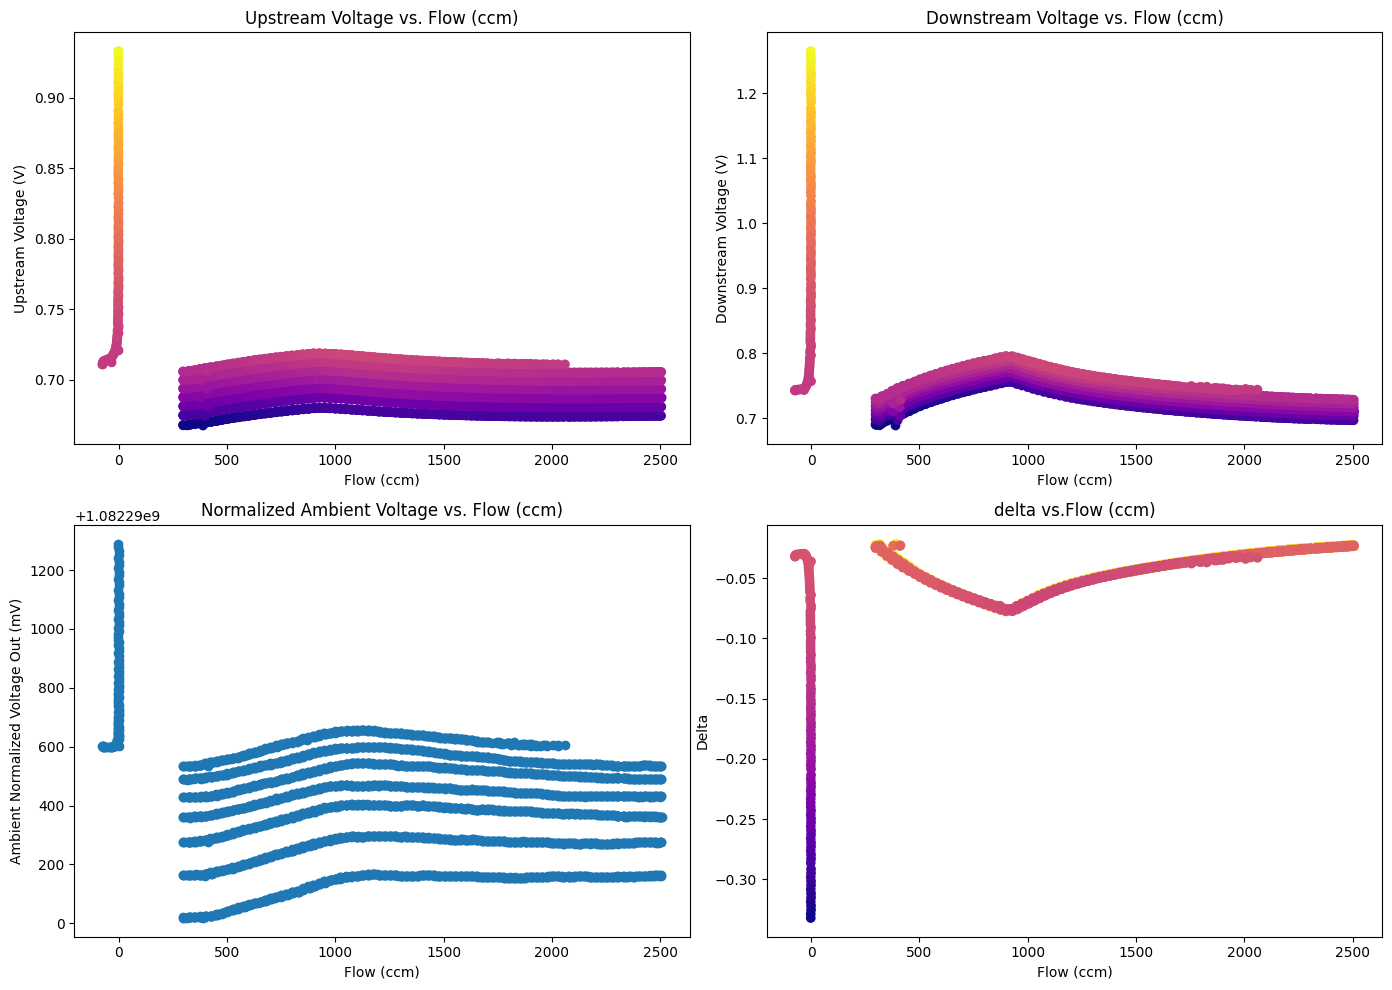

In [ ]:
USE_TIME = False
OFFSET_START = True
NORMALIZE = False

TEST_LENGTH = 445

df = update_data()
df.to_csv('test_backup.csv')
print(f'Pulled test_log.csv with length: {len(df)}')
orig_copy = df.copy()
start = 916 if OFFSET_START else 0
end = start+TEST_LENGTH*6
df = df.iloc[start:end]
if len(df) < 1:
    raise SystemExit('No data was found')

t = df['flow_actual'] if not USE_TIME else (df['SYS'] - min(df['SYS']))/1000
t_label = 'Flow (ccm)' if not USE_TIME else 'Time (s)'
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax_up, ax_down, ax_amb, ax_flow = axes.flatten()

# Upstream Voltage
ax_up.set_xlabel(t_label)
ax_up.set_ylabel('Upstream Voltage (V)')
ax_up.set_title(f'Upstream Voltage vs. {t_label}')

# Downstream Voltage
ax_down.set_xlabel(t_label)
ax_down.set_ylabel('Downstream Voltage (V)')
ax_down.set_title(f'Downstream Voltage vs. {t_label}')

# Ambient Normalized Voltage
ax_amb.set_xlabel(t_label)
ax_amb.set_ylabel('Ambient Normalized Voltage Out (mV)')
ax_amb.set_title(f'Normalized Ambient Voltage vs. {t_label}')

# Flow
window_size = 10
ax_flow.set_xlabel(t_label)

ax_flow.set_ylabel('Flow' if USE_TIME else 'Delta')
ax_flow.set_title(f'{'Flow' if USE_TIME else 'delta'} vs.{t_label}')

plt.tight_layout()



if NORMALIZE:
    ax_up.scatter(t,df['UP']-min(df['UP']),c=df['AMB32'],cmap='plasma');
    ax_down.scatter(t,((df['DOWN']-min(df['DOWN']))).rolling(window=1,center=False).mean(),c=df['AMB32'],cmap='plasma');
    ax_amb.scatter(t,df['AMB32']-min(df['AMB32']));
    # ax_amb_norm.scatter(df.index,(df['AMB32']-min(df['AMB32'])).rolling(window=window_size, center=True).mean());
    ax_flow.scatter(t,df['UP']-min(df['UP']) - ((df['DOWN']-min(df['DOWN']))),c=df['AMB32'],cmap='plasma_r');
else :
    ax_up.scatter(t,df['UP'],c=df['AMB32'],cmap='plasma');
    ax_down.scatter(t,(df['DOWN']),c=df['AMB32'],cmap='plasma');
    ax_amb.scatter(t,df['AMB32']);
    # ax_amb_norm.scatter(df.index,(df['AMB32']-min(df['AMB32'])).rolling(window=window_size, center=True).mean());
    ax_flow.scatter(t,df['UP'] - df['DOWN'] if not USE_TIME else df['flow_actual'],c=df['AMB32'],cmap='plasma_r');


plt.show()

# plt.scatter(t,df['flow_actual'])
# plt.show()




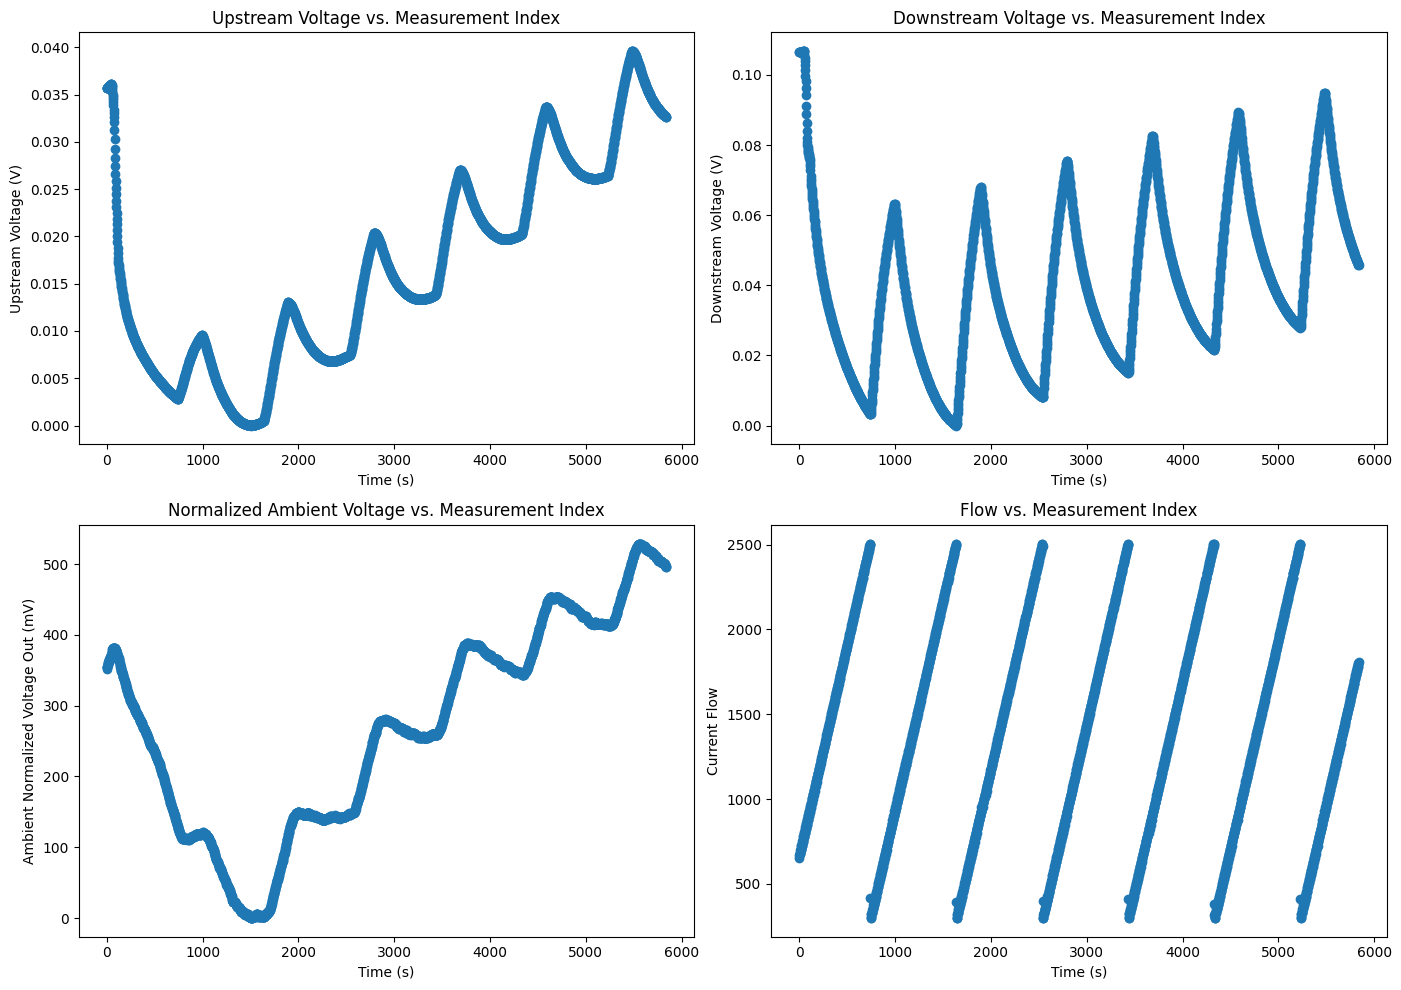

In [155]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax_up, ax_down, ax_amb, ax_flow = axes.flatten()

# Upstream Voltage
ax_up.set_xlabel(t_label)
ax_up.set_ylabel('Upstream Voltage (V)')
ax_up.set_title('Upstream Voltage vs. Measurement Index')

# Downstream Voltage
ax_down.set_xlabel(t_label)
ax_down.set_ylabel('Downstream Voltage (V)')
ax_down.set_title('Downstream Voltage vs. Measurement Index')

# Ambient Normalized Voltage
ax_amb.set_xlabel(t_label)
ax_amb.set_ylabel('Ambient Normalized Voltage Out (mV)')
ax_amb.set_title('Normalized Ambient Voltage vs. Measurement Index')

# Flow
window_size = 10
ax_flow.set_xlabel(t_label)
ax_flow.set_ylabel('Current Flow')
ax_flow.set_title('Flow vs. Measurement Index')

plt.tight_layout()


ax_up.scatter(t,df['UP']-min(df['UP']));
ax_down.scatter(t,((df['DOWN']-min(df['DOWN']))).rolling(window=1, center=False).mean());
ax_amb.scatter(t,df['AMB32']-min(df['AMB32']));
# ax_amb_norm.scatter(df.index,(df['AMB32']-min(df['AMB32'])).rolling(window=window_size, center=True).mean());
ax_flow.scatter(t,df['flow_actual']);


In [55]:
dut_df = split_df[1]
print(dut_df.head())
dut_df['UP_CONV'] = (dut_df['UP'] + 9.8)/196.686
dut_df['DOWN_CONV'] = (dut_df['DOWN'] + 9.8)/196.686
gain = 499/2.55+1
V_bias = 0.0500785546
def rtd_to_temperature(R, R0=100.0, alpha=0.00385):
    A = 3.9083e-3
    B = -5.775e-7
    
    # Solve quadratic for temperature
    discriminant = A**2 - 4*B*(1 - R/R0)
    if discriminant < 0:
        raise ValueError("Resistance out of valid range for PT100.")
    
    T = (-A + discriminant**0.5) / (2*B)
    return T
dut_df['R_UP_EST'] = (dut_df['UP_CONV'] / 481e-6)
dut_df['TEMP_EST'] = dut_df['R_UP_EST'].apply(rtd_to_temperature)
print(min(dut_df['TEMP_EST']),max(dut_df['TEMP_EST']),max(dut_df['TEMP_EST'])-min(dut_df['TEMP_EST']))
print(dut_df.head())



NameError: name 'split_df' is not defined

In [56]:
df.to_csv('iforgottosave.csv', index=False)